##### Instructions
- Keep the original structure, you may add additional code cells and/or mark-down cells for clarity, legibility and/or structure.
- Add the required descriptions, explanations, justifications to the mark-down cells. You can find more mark-down tips & tricks online, for example [here](https://jupyter-notebook.readthedocs.io/en/stable/examples/Notebook/Working%20With%20Markdown%20Cells.html) and [here](https://www.ibm.com/docs/en/watson-studio-local/1.2.3?topic=notebooks-markdown-jupyter-cheatsheet)

# EXAM03: Data Science Group Assignment - Iteration 1

**Group name:** Databazen😎

**Student names & numbers:**
* [Xander UijtdeHaag] - [Student no.100546]
* [Jamie Eversdijk] - [Student no.000101617]
* [Jero den Exter] - [Student no.000100883]


---

## 0. Iteration setup

**Import libraries**

In [1]:
%pip install pandas
%pip install matplotlib
%pip install scikit-learn

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


**Load dataset(s)**

In [5]:
df = pd.read_csv('Data/Sus_scrofa_prepared.csv')

---

## 1. Business Understanding
*Rubric: LO 6.4D (Reflection on Process)**

**Business objective(s)**

Wij willen inzicht krijgen in de leefgebieden in Nederland van waar wilde zwijnen het vaakst voorkomen van op zijn minst 20 verschillende plaatsen zodat wij weten waar de zwijnen leven tussen 2010 en 2025.


**Acceptence criteria(s)**
Duidelijk inzicht voor waar de meeste wilde zwijnen leven in Nederland

Minstens 20 verschillende plaatsen halen uit de data.

Alleen data tussen 2010 en 2025 gebruiken

Gebieden met hoge en lage hoeveelheden van zwijnen zijn te scheiden.

**Data management goal(s)**

We houden de data netjes en overzichtelijk in een CSV-bestand op onze GitHub. We zorgen ervoor dat de data betrouwbaar blijft door goed te checken of er fouten of missende data is in de dataset.

**Data mining goal(s)**
Met behulp van een classificatie model inzicht krijgen waar de meeste wilde zwijnen van Nederland leven tussen 2010 en 2025. Wij hebben gekozen voor classificatie omdat wij een categorie gaan voorspellen. Namelijk of de locatie veel zwijnen heeft of minder. Regressie zou handig zijn om preciese aantallen te voorspellen.
**Success criteria**


Het model heeft een recall van 75% en een precision van op zijn minst 80% op de geclassificeerde gebieden. De criteria moet behaald zijn bij de evaluatie van het model op de testset.


*Determine success criteria for this iteration (the benchmark)*

Recall (75%)
Recall kijkt naar van alle gebieden met "veel" zwijnen hoeveel het model er correct heeft voorspeld. Het model zal dus kijken of het alle zwijngebieden die echt zijn ook goed heeft voorspeld. Wij kiezen voor een recall van 75%, omdat dit ervoor zorgt dat de meest belangrijke leefgebieden worden meegenomen. Dit is een realistische grens in onze ogen.

Precision (80%)
Precision geeft aan hoe vaak een voorspeld gebied met “veel” wilde zwijnen ook daadwerkelijk klopt. Wij kiezen voor een precision van 80%, omdat het belangrijk is dat de gebieden die het model aanwijst als "veel" wilde zwijnen ook echt betrouwbaar zijn. Dit zorgt ervoor dat er minder foute gegevens zijn over de zwijnen. Wij vinden dus het correct voorspellen van de gebieden met "veel" wilde zwijnen iets belangrijker als het vinden van alle gebieden met "veel" wilde zwijnen.


**Exploratory data analysis**

Hier hebben we de dataset geanalyseerd om er achter te komen welke info er beschikbaar is over de wilde zwijen. Door df.info() te doen zien we dat de dataset heel groot is met 12.558.786 rijen en 6 kolommen. De kolommen hebben geografische coördinaten (decimalLatitude, decimalLongitude), wat nodig is om de locatie van de zwijnen te bepalen, de datum van de waarneming (eventDate), wat cruciale informatie is om te zien op het binnen 2010 en 2025 valt, en het aantal waarnemingen, het totaal aantal in de waarnemingen (total_observations), wat helpt met het vinden van "hotspots". De kolom Sus scrofa is onze doelvariabele voor het identificeren van de zwijnen.

Met df.describe() zien we dat de coördinaten (Latitude rond 52.2 en Longitude rond 5.5) de goede waarden zijn voor Nederland. Het gemiddelde aantal waarneming per record is laag, maar er zijn wel uitschieters tot wel 1.637 waarnemingen in de speciesgroup_observations. Met de check df.isna().sum() laten we zien dat de dataset bijna volledig is, er missen maar 2 waarden in de kolom total_observations. Dit is heel weinig vergeleken met het toaal van 12 miljoen rijen, dus de kwaliteit van de data is hoog. Aan de hand van de EDA weten we dat de data representatief is voor Nederland en dat de data schoon genoeg is om mee te werken.

Door df.describe() zien we dat veel waarnemingen van zwijnen veel geclusterd zijn. Het is mogelijk dat er een bias is van meldingen in gebieden waar veel mensen wandelen, terwijl er in rustige gebieden misschien ook zwijnen zitten die niet gemeld worden. Hier moeten we rekening mee houden als we ons model trainen.

In [ ]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 12558786 entries, 0 to 12558785
Data columns (total 6 columns):
 #   Column                     Dtype  
---  ------                     -----  
 0   decimalLatitude            float64
 1   decimalLongitude           float64
 2   eventDate                  str    
 3   total_observations         float64
 4   speciesgroup_observations  int64  
 5   Sus scrofa                 Int64  
dtypes: Int64(1), float64(3), int64(1), str(1)
memory usage: 586.9 MB


In [5]:
df.head()

,decimalLatitude,decimalLongitude,eventDate,total_observations,speciesgroup_observations,Sus scrofa
0,50.75,5.65,2010-01-01,0.0,0,0
1,50.75,5.65,2010-01-02,26.0,0,0
2,50.75,5.65,2010-01-03,3.0,0,0
3,50.75,5.65,2010-01-04,0.0,0,0
4,50.75,5.65,2010-01-05,0.0,0,0


In [11]:
df.describe()

,decimalLatitude,decimalLongitude,eventDate,total_observations,speciesgroup_observations,Sus scrofa,year,month,lat_round,lon_round,total_observations_scaled,is_hotspot
count,1.255876e+07,1.255876e+07,12558756,1.255876e+07,1.255876e+07,1.255876e+07,1.255876e+07,1.255876e+07,1.255876e+07,1.255876e+07,1.255876e+07,1.255876e+07
mean,5.223006e+01,5.532783e+00,2017-12-31 11:59:59.999999744,8.117018e+00,2.238276e-01,2.179117e-03,2.017500e+03,6.522930e+00,5.223006e+01,5.532783e+00,8.113772e-05,9.873589e-04
min,5.075000e+01,3.350000e+00,2010-01-01 00:00:00,0.000000e+00,0.000000e+00,0.000000e+00,2.010000e+03,1.000000e+00,5.075000e+01,3.350000e+00,0.000000e+00,0.000000e+00
25%,5.170000e+01,4.900000e+00,2013-12-31 18:00:00,0.000000e+00,0.000000e+00,0.000000e+00,2.013750e+03,4.000000e+00,5.170000e+01,4.900000e+00,0.000000e+00,0.000000e+00
50%,5.220000e+01,5.650000e+00,2017-12-31 12:00:00,1.000000e+00,0.000000e+00,0.000000e+00,2.017500e+03,7.000000e+00,5.220000e+01,5.650000e+00,9.996002e-06,0.000000e+00
75%,5.280000e+01,6.200000e+00,2021-12-31 06:00:00,6.000000e+00,0.000000e+00,0.000000e+00,2.021250e+03,1.000000e+01,5.280000e+01,6.200000e+00,5.997601e-05,0.000000e+00
max,5.350000e+01,7.200000e+00,2025-12-31 00:00:00,1.000400e+05,1.637000e+03,1.000000e+02,2.025000e+03,1.200000e+01,5.350000e+01,7.200000e+00,1.000000e+00,1.000000e+00
std,6.605211e-01,8.748856e-01,NaN,3.920472e+01,1.979683e+00,7.551124e-02,4.609698e+00,3.448703e+00,6.605211e-01,8.748856e-01,3.918904e-04,3.140675e-02


In [10]:
df.isna().sum()

decimalLatitude              0
decimalLongitude             0
eventDate                    0
total_observations           0
speciesgroup_observations    0
Sus scrofa                   0
year                         0
month                        0
lat_round                    0
lon_round                    0
total_observations_scaled    0
is_hotspot                   0
dtype: int64

---

## 2. Data Understanding
*Rubric: LO 7.3Q (Visuals) & LO 6.4C (Process)*

**Data exploration**

*Include summary statistics and descriptions of data types below. Describe your findings.*

Tijdens de eda zijn we erachter gekomen dat datatypes zijn float, object en een int. Wat hier van toepassing is dat de Sus scrofa een object is en om deze mee te brengen in visualisaties moet dit veranderd worden naar een integer.

In [3]:
# Controleer de kolomtype-conversie voor 'Sus scrofa'
df['Sus scrofa'] = pd.to_numeric(df['Sus scrofa'], errors='coerce').astype('Int64')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12558786 entries, 0 to 12558785
Data columns (total 6 columns):
 #   Column                     Dtype  
---  ------                     -----  
 0   decimalLatitude            float64
 1   decimalLongitude           float64
 2   eventDate                  object 
 3   total_observations         float64
 4   speciesgroup_observations  int64  
 5   Sus scrofa                 Int64  
dtypes: Int64(1), float64(3), int64(1), object(1)
memory usage: 586.9+ MB


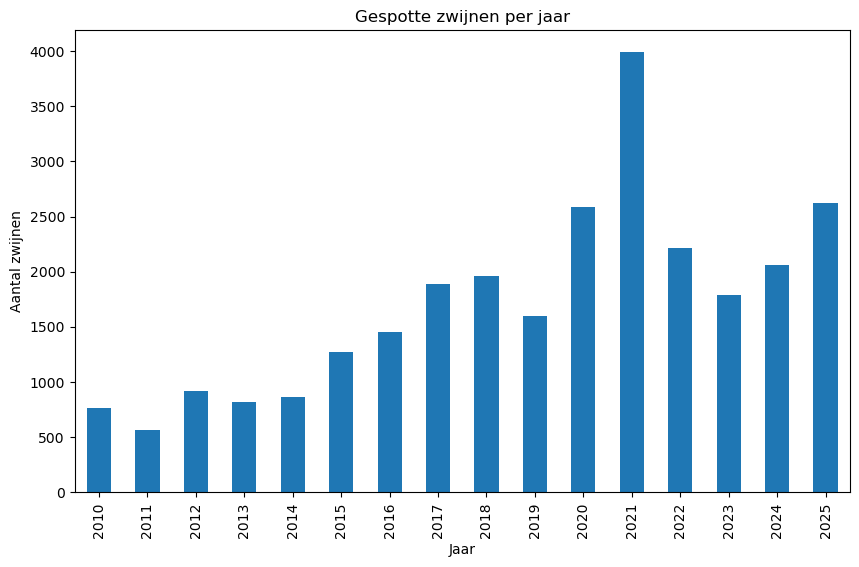

In [9]:
# Maak een barchart van de zwijnen per jaar uit eventDate

df['eventDate'] = pd.to_datetime(df['eventDate'], errors='coerce')
df['year'] = df['eventDate'].dt.year

# Jaarlijkse som van de zwijnen per jaar
perjaar = df.groupby('year')['Sus scrofa'].sum().dropna()

ax = perjaar.plot(kind='bar', figsize=(10, 6))
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{int(x)}'))
plt.title('Gespotte zwijnen per jaar')
plt.xlabel('Jaar')
plt.ylabel('Aantal zwijnen')
plt.show()

In deze grafiek zie je het aantal gespotte zwijnen van 2010 t/m 2026. Wat hier vooral opvalt is de piek in 2021 vergeleken met de jaren daarna. Normaal gezien als je van 2020 naar 2021 gaat met zo'n groei kan het aan meerdere factoren liggen, maar het feit dat de hoeveelheid zwijnen gespot weer terug zakt in 2022 is frappant. Dit verschijnsel kan liggen aan het feit dat er gewoon meer zwijnen waren in 2021 of dat mensen weer naar buiten gingen vanwege de piek van coronavirus het jaar ervoor. Over het coronavirus gesproken is het apart dat 2020 het 2 na hoogste getal is van alle jaren, omdat er toen juist werd geadviseerd om zo veel mogelijk binnen te blijven. 

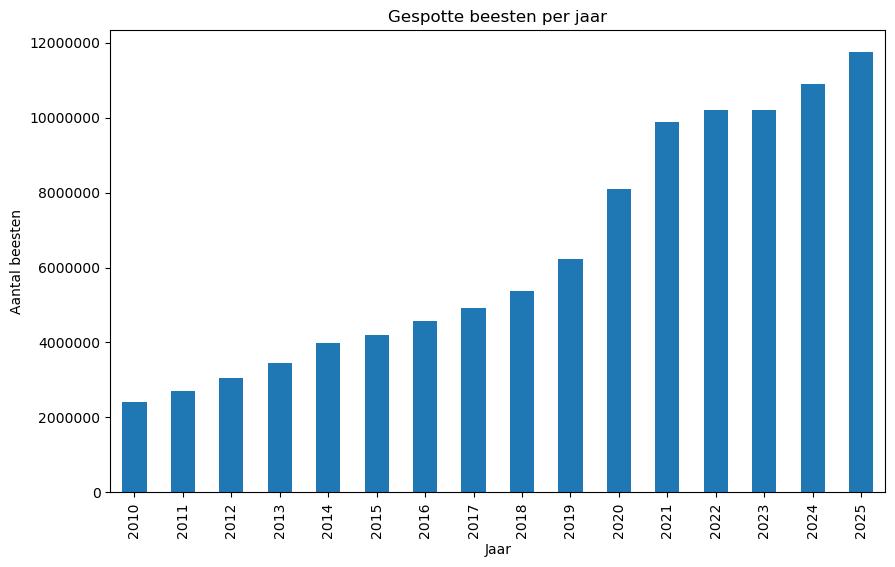

In [7]:
df['eventDate'] = pd.to_datetime(df['eventDate'], errors='coerce')
df['year'] = df['eventDate'].dt.year

# Jaarlijkse som van de beesten per jaar
perjaar = df.groupby('year')['total_observations'].sum().dropna()

ax = perjaar.plot(kind='bar', figsize=(10, 6))
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{int(x)}'))
plt.title('Gespotte beesten per jaar')
plt.xlabel('Jaar')
plt.ylabel('Aantal beesten')
plt.show()

Deze grafiek is te zien hoeveel keer er een foto werd ingediend in de app per jaar, hier is het duidelijk dat er in de app steeds meer beesten worden ingediend in de loop van de jaren. Dit ligt vooral aan het feit dat de app populairder is geworden vergeleken met vroeger. Dit verklaart ook de steigende lijn bij de zwijnen grafiek.

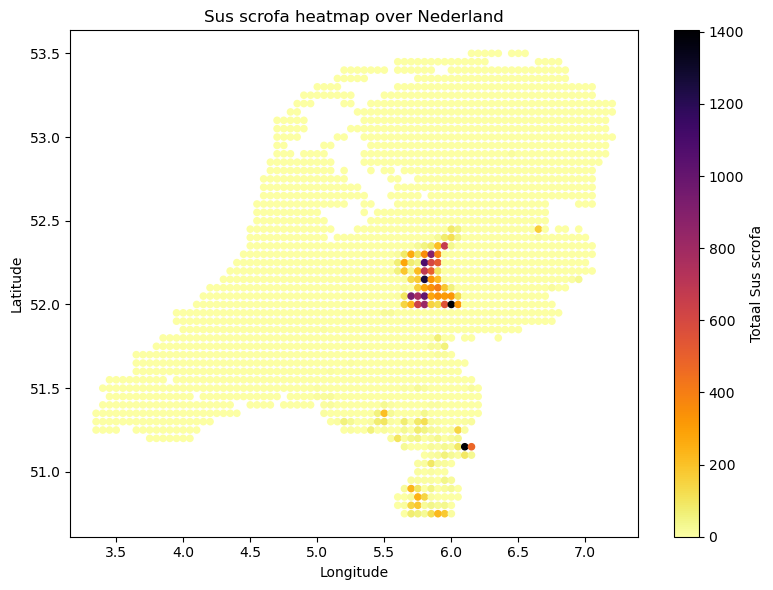

In [6]:
# Heatmap van Sus scrofa over Nederland met longitude en latitude
import numpy as np

# Zorg dat de locatiekolommen numeriek zijn
df['decimalLatitude'] = pd.to_numeric(df['decimalLatitude'], errors='coerce')
df['decimalLongitude'] = pd.to_numeric(df['decimalLongitude'], errors='coerce')

heatmap_df = df.dropna(subset=['decimalLatitude', 'decimalLongitude', 'Sus scrofa'])

# Aggregeer Sus scrofa per locatie
agg_df = heatmap_df.groupby(['decimalLongitude', 'decimalLatitude'])['Sus scrofa'].sum().reset_index()

plt.figure(figsize=(8, 6))
plt.scatter(
    agg_df['decimalLongitude'],
    agg_df['decimalLatitude'],
    c=agg_df['Sus scrofa'].astype(float),
    cmap='inferno_r',
    s=20
)
plt.colorbar(label='Totaal Sus scrofa')
plt.title('Sus scrofa heatmap over Nederland')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.tight_layout()
plt.show()

Deze heatmap geeft weer waar zwijnen het meeste worden gespot, wat hier heel duidelijk opvalt is dat er zogenaamd zwijnen zijn gespot rechtsonderin van de map. Dit kan betekenen dat iemand zin had om bijvoorbeeld in australië zwijnen te publiceren op de app, of dat de longitude en lattitude wat wordt gebruikt om de locatie te bepalen verkeerd zijn ingevuld in de dataset. We gaan dus uitzoeken hoe dit is gebeurd en of dit op te lossen is zodat we dieper in de map kunnen kijken aangezien door deze verschijnselen de hele map is uitgezoomd, en dus niet goed kunnen zien hoe dit in Nederland is verdeeld.

Dit laat zien welke locaties precies de meeste wilde zwijnen hebben. Het is wel van de hele dataset en niet van een bepaald jaar. Dit geeft meer duidelijkheid bij de kaart hierboven

In [15]:
df.groupby(['decimalLatitude', 'decimalLongitude'])['Sus scrofa'] \
  .sum() \
  .sort_values(ascending=False)

decimalLatitude  decimalLongitude
51.15            6.10                1404
52.00            6.00                1399
52.15            5.80                1250
52.25            5.80                1087
52.05            5.80                1014
                                     ... 
51.95            5.25                   0
                 5.20                   0
                 5.15                   0
                 5.05                   0
53.50            6.55                   0
Name: Sus scrofa, Length: 2149, dtype: int64

Dit stuk code laat zien bij welke locatie wanneer de eerste en laatste waargenomen hotspot was en ook gelijk hoeveel hotspots het is geweest tussen deze tijd in. Dit is handig om te weten welke locaties hotspots waren en hoevaak.

In [25]:
df.query('is_hotspot == 1') \
.groupby(['decimalLatitude', 'decimalLongitude']) ['eventDate'] \
.agg(['min', 'max', 'count'])

min        max  count
decimalLatitude decimalLongitude                             
50.75           5.70             2014-01-12 2025-12-12     48
                5.75             2011-02-13 2025-04-16     27
                5.80             2010-05-03 2025-06-22     10
                5.85             2010-04-01 2025-05-19     78
                5.90             2010-03-04 2025-11-30    113
...                                     ...        ...    ...
52.90           6.45             2022-06-25 2024-08-06     11
                6.60             2016-09-10 2016-09-10      1
52.95           7.10             2022-07-30 2022-07-30      1
53.10           7.00             2025-05-05 2025-05-05      1
53.20           6.50             2019-02-06 2019-02-06      1

[281 rows x 3 columns]

---
## 3. Data Preparation

We bereiden de dataset voor om gebieden met veel wilde zwijnen te classificeren tussen 2010 en 2025.

**Data Integratie**

De originele dataset heeft waarnemingen van heel veel diersoorten, hierdoor zijn er heel veel rijen waar geen wilde zwijnen worden gespot. Dit maakt het een zero-inflated dataset. Door deze data bewust te behouden leert het classificatiemodel straks niet alleen hoe de leefomgeving eruit ziet van het wilde zwijn, maar leert het ook de kenmerken herkennen van gebieden waar de wilde zwijnen juist niet zijn. Deze data functioneert binnen ons project als sampling zeroes. Omdat deze rijen ook de observer activity bijhouden, voorkomt dit dat ons model bias oploopt.

**Data cleaning en scaling**

Uit onze Exploratory data analysis bleek dat er maar 2 waarden misten in de kolom `total_observations`. Omdat er maar 2 zijn op het totaal van 12,5 miljoen, gooien we deze rijen weg met `dropna()`. Handmatig het gemiddelde invullen is onnodig en zou de data alleen maar op een kunstmatige manier aanpassen, wat niet nodig is.

In de data zitten extreme uitschieters die volgens de Z-score methode (Z > 3) ver buiten het normale bereik liggen. Omdat de meeste meldingen vaak rond de 1 of 2 zwijnen zit, is de data extreem rechts-scheef verdeeld. We vinden dat een StandardScaler niet goed werkt omdat deze de data centreert rond het gemiddelde wat door de extreme uitschieters wordt scheefgetrokken. Daarom kiezen we voor de Min-Max scaling. We zetten alle aantallen om naar een waarde tussen 0 and 1, waardoor het model stabieler kan trainen.

**Data encoding en labeling**

* **Features en target:** Onze onafhankelijke variabelen worden de locaties en tijden, onze doelvariabele wordt `is_hotspot`.
* **Gebieden maken:** Exacte GPS-coördinaten zijn te specifiek voor het model om patronen te ontdekken. Daarom ronden we de `decimalLatitude` and `decimalLongitude` af op 2 decimalen. Op deze manier maken we vakken van ongeveer 1 bij 1 kilometer. Als er in een vak een wild zwijn is waargenomen (`Sus scrofa >= 1`) en er zijn meer dan 5 waarnemingen in de kolom `total_observations`, wordt het gelabeld als een hotspot en krijgt het de label 1, anders krijgt het een 0. Dit sluit aan op ons acceptance criterium.

**Dataformat aanpassen**

Ons classificatiemodel accepteert alleen data vol met getallen, zonder tekst of lege cellen. Doordat we de `eventDate` opsplitsen in `year` en `month` wat nu getallan zijn, voldoet de dataset nu aan de wiskundige eisen voor het algoritme voor de modeling.

In [4]:
df_clean = df.dropna(subset=['total_observations']).copy()
df_clean['Sus scrofa'] = pd.to_numeric(df_clean['Sus scrofa'], errors='coerce').fillna(0).astype(int)

df_clean['eventDate'] = pd.to_datetime(df_clean['eventDate'])
df_clean = df_clean[df_clean['eventDate'].dt.year.between(2010, 2025)]

df_clean['year'] = df_clean['eventDate'].dt.year
df_clean['month'] = df_clean['eventDate'].dt.month
df_clean['lat_round'] = df_clean['decimalLatitude'].round(2)
df_clean['lon_round'] = df_clean['decimalLongitude'].round(2)

df_clean['total_observations_scaled'] = MinMaxScaler().fit_transform(df_clean[['total_observations']])
df_clean['is_hotspot'] = ((df_clean['Sus scrofa'] >= 1) & (df_clean['total_observations'] > 5)).astype(int)

print("Eindverdeling Hotspots:")
print(df_clean['is_hotspot'].value_counts())

df_clean.to_csv('Data/Sus_scrofa_prepared.csv', index=False)

Eindverdeling Hotspots:
is_hotspot
0    12546356
1       12400
Name: count, dtype: int64


---

## 4. Modeling
*Rubric: LO 6.4C (Data Science Steps)*

**Model setup**
*Describe and justify the creation of your simple benchmark model to predict Galactic_Credits*

**Testing and performance**
*Describe how you tested the model and interpret the metrics. Make sure to present the metrics in a clear overview.*

---

## 6 Personal Contribution
*Rubric: LO 7.3P (Equal Contribution)*

| Student name | Contribution | Personal lessons learned |
| :--- | :--- | :--- |
| Xander UijtdeHaag | Business understanding, Data preperation, Evaluation | Ik heb veel geleerd over het belang en het nut van Data-driven worden en het doel van data-driven worden als bedrijf. Ook heb ik technisch veel geleerd bij Data preperation en dit lukte na wat dingen uitzoeken best makkelijk. Ook heb ik veel geleerd over hoe de opdracht eruit ziet en hoe data science een beetje in elkaar zit |
| Jamie Eversdijk | Geheel modeling, Evaluation van findings mae en rmse | Ik heb geleerd hoe je met een baseline model en een train-test split een eerlijk nulpunt bepaalt voor de voorspellingen. Door het gemiddelde te gebruiken en dit te testen met MAE en MSE, maken deze metrics het mogelijk om voorspellingen met feitelijke informatie te beoordelen. |
| Jero den Exter | Data understanding alles gemaakt, Data preperation poging tot het maken van een logische code van gecleande data, maar miste wel wat delen. Evaluation | Veel geleerd over het werken met een grote dataset. Het data preperation gedeelte vond ik wel lastig. Geleerd over data understanding en alle handige python commands daarbij. Verder ook geleerd hoe je een histogram kan maken met python. Het deleete van Data preperation vond ik wel het moeilijkst. Ik vond de spelfouten nog al lastig uit de dataset te halen. Dit heeft iemand anders ook uiteindelijk over gepakt. |